# Fashion-MNIST — Dense baseline + CNN

Cleaned version of the original notebook.

Goals:
1. load and check the data only once;
2. create one fixed train/validation/test structure;
3. keep a Dense model as a baseline;
4. train a CNN on exactly the same data;
5. inspect learning curves for overfitting;
6. evaluate both models on the untouched test set;
7. inspect confusion matrices, errors and CNN feature maps.

The code is deliberately commented for learning.


In [1]:
# `os` lets Python work with operating-system settings.
import os

# Keras must know which backend to use BEFORE Keras itself is imported.
os.environ["KERAS_BACKEND"] = "torch"

# NumPy provides numerical arrays and array operations.
import numpy as np

# Matplotlib is used for graphs and displaying images.
import matplotlib.pyplot as plt

# Seaborn is used here mainly for the confusion-matrix heatmap.
import seaborn as sns

# Keras is the high-level deep-learning framework used in this notebook.
import keras

# Sequential builds a model as a simple ordered stack of layers.
# Model is used later to create models that expose intermediate CNN layers.
from keras.models import Sequential, Model

# Input defines the input shape.
# Flatten converts an image/tensor into one vector.
# Dense is a fully connected neural-network layer.
# Reshape adds the explicit grayscale channel required by Conv2D.
# Rescaling changes pixel values from 0–255 to 0–1.
# Conv2D applies learned convolution filters to images.
# MaxPooling2D reduces the spatial dimensions of feature maps.
# Dropout randomly disables part of a layer during training to reduce overfitting.
# RandomTranslation, RandomRotation and RandomZoom perform data augmentation.
from keras.layers import (
    Input,
    Flatten,
    Dense,
    Reshape,
    Rescaling,
    Conv2D,
    MaxPooling2D,
    Dropout,
    RandomTranslation,
    RandomRotation,
    RandomZoom,
)

# Adam is the optimizer that updates model weights from calculated gradients.
from keras.optimizers import Adam

# SparseCategoricalCrossentropy is appropriate for integer labels 0–9.
from keras.losses import SparseCategoricalCrossentropy

# Fashion-MNIST contains 28×28 grayscale clothing images in 10 classes.
from keras.datasets import fashion_mnist

# train_test_split separates the original training data into train and validation sets.
from sklearn.model_selection import train_test_split

# These metrics help evaluate classification performance after training.
from sklearn.metrics import confusion_matrix, classification_report

# Print versions/backend so the environment is visible and reproducible.
print("Keras version:", keras.__version__)
print("Keras backend:", keras.backend.backend())


Keras version: 3.15.1
Keras backend: torch


In [5]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")
print("Keras backend:", keras.backend.backend())

CUDA available: True
GPU: NVIDIA RTX PRO 4000 Blackwell
Keras backend: torch


## 1. Load the data once

The original Fashion-MNIST split contains 60,000 training-side images and 10,000 test images.
We keep the original 60,000 in variables ending in `_full`, then create a validation set from them.
This prevents accidentally overwriting `x_train` later.


In [2]:
# Load Fashion-MNIST exactly once.
(x_train_full, y_train_full), (x_test, y_test) = fashion_mnist.load_data()

# Split the original 60,000 training-side images:
# 80% = 48,000 actual training images.
# 20% = 12,000 validation images.
# `stratify` preserves approximately the same class proportions in both sets.
# `random_state=1` makes the split reproducible.
x_train, x_val, y_train, y_val = train_test_split(
    x_train_full,
    y_train_full,
    test_size=0.20,
    random_state=1,
    stratify=y_train_full,
)

# Check the three datasets before any model is trained.
print("Train:     ", x_train.shape, y_train.shape)
print("Validation:", x_val.shape, y_val.shape)
print("Test:      ", x_test.shape, y_test.shape)

# These assertions stop the notebook immediately if the split is not what we expect.
assert x_train.shape == (48000, 28, 28)
assert x_val.shape == (12000, 28, 28)
assert x_test.shape == (10000, 28, 28)

# Confirm that raw Fashion-MNIST pixels are still stored as integers from 0 to 255.
print("Pixel range:", x_train.min(), "to", x_train.max())
print("Data type:", x_train.dtype)


Train:      (48000, 28, 28) (48000,)
Validation: (12000, 28, 28) (12000,)
Test:       (10000, 28, 28) (10000,)
Pixel range: 0 to 255
Data type: uint8


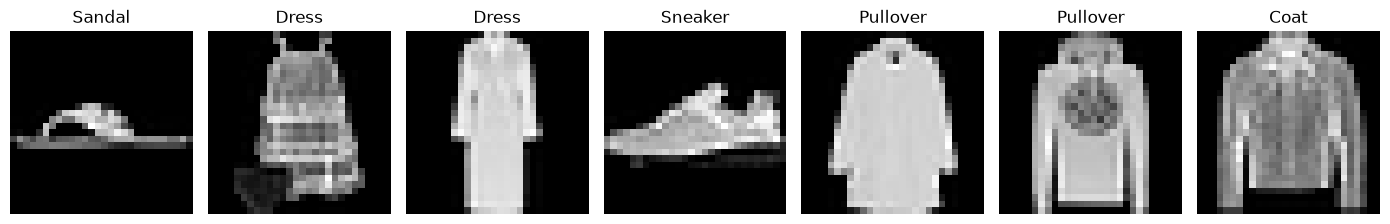

In [3]:
# Human-readable names corresponding to numeric labels 0–9.
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

# Display seven reproducible random training examples.
rng = np.random.default_rng(42)

# Create one figure containing seven images instead of seven separate figures.
plt.figure(figsize=(14, 3))

# Repeat seven times to display seven examples.
for position in range(7):
    # Choose a random training-image index.
    index = rng.integers(0, len(x_train))

    # Create one position in a 1×7 image grid.
    plt.subplot(1, 7, position + 1)

    # Display the selected grayscale image.
    plt.imshow(x_train[index], cmap="gray")

    # Convert the numeric label to a readable class name.
    plt.title(class_names[y_train[index]])

    # Hide axes because pixel coordinates are not needed here.
    plt.axis("off")

# Prevent titles/images from overlapping.
plt.tight_layout()

# Display the complete figure.
plt.show()


## 2. Dense baseline

This model deliberately removes the 2D image structure with `Flatten`.
It provides a baseline against which the CNN can be compared.

Both models use the same train/validation/test sets.


In [4]:
# Define a function so a fresh Dense model can be recreated whenever needed.
def build_dense_model() -> Sequential:

    # Build a simple sequence of layers.
    model = Sequential([
        # One input example is a 28×28 grayscale image.
        Input(shape=(28, 28)),

        # Convert pixels from 0–255 to 0–1 inside the model.
        Rescaling(1.0 / 255),

        # Convert 28×28 = 784 pixels into one vector of 784 values.
        Flatten(),

        # Receive 784 values and produce 64 learned features.
        Dense(64, activation="relu"),

        # Receive 64 values and produce another 64 learned features.
        Dense(64, activation="relu"),

        # Receive 64 values and produce 128 learned features.
        Dense(128, activation="relu"),

        # Produce probabilities for the 10 Fashion-MNIST classes.
        Dense(10, activation="softmax"),
    ])

    # Configure how the network learns and how its performance is measured.
    model.compile(
        # Adam updates the weights using gradients calculated by backpropagation.
        optimizer=Adam(),

        # Integer class labels 0–9 require sparse categorical cross-entropy.
        loss=SparseCategoricalCrossentropy(),

        # Accuracy measures the proportion of correctly classified images.
        metrics=["accuracy"],
    )

    # Return the configured model.
    return model


# Create one fresh Dense baseline model.
dense_model = build_dense_model()

# Display layer shapes and parameter counts.
dense_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64,010 (250.04 KB)

 Trainable params: 64,010 (250.04 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Train the Dense baseline and save its history for later analysis.
dense_history = dense_model.fit(
    # Images used to learn model weights.
    x_train,

    # Correct labels corresponding to the training images.
    y_train,

    # Number of training examples used before each optimizer update.
    batch_size=512,

    # Maximum number of complete passes through the training data.
    epochs=20,

    # Data used only to monitor generalization during training.
    validation_data=(x_val, y_val),

    # Show one progress line per epoch.
    verbose=1,
)


Epoch 1/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7042 - loss: 0.8794 - val_accuracy: 0.8090 - val_loss: 0.5321
Epoch 2/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8338 - loss: 0.4723 - val_accuracy: 0.8369 - val_loss: 0.4614
Epoch 3/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8533 - loss: 0.4133 - val_accuracy: 0.8522 - val_loss: 0.4213
Epoch 4/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8621 - loss: 0.3874 - val_accuracy: 0.8622 - val_loss: 0.3880
Epoch 5/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8696 - loss: 0.3663 - val_accuracy: 0.8699 - val_loss: 0.3652
Epoch 6/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8747 - loss: 0.3481 - val_accuracy: 0.8710 - val_loss: 0.3638
Epoch 7/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8783 - loss: 0.3367 - val_accuracy: 0.8766 - val_loss: 0.3446
Epoch 8/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8815 - loss: 0.3283 - val_accuracy: 0.8730 - val_loss:

## 3. Function to check fitting / overfitting

Interpretation:

- training loss ↓ and validation loss ↓: learning is healthy;
- training loss ↓ while validation loss starts ↑: overfitting is beginning;
- a growing train/validation accuracy gap is another overfitting warning.

The best validation-loss epoch is useful when deciding how many epochs are appropriate.


Best validation-loss epoch: 18
Final training accuracy:    0.9081
Final validation accuracy:  0.8854
Final training loss:        0.2459
Final validation loss:      0.3217


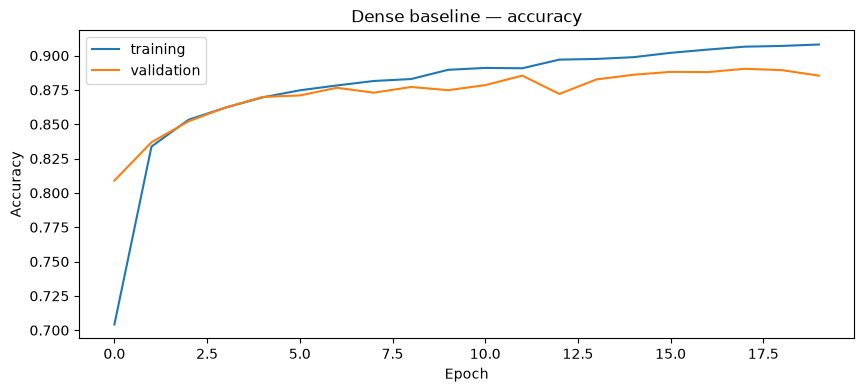

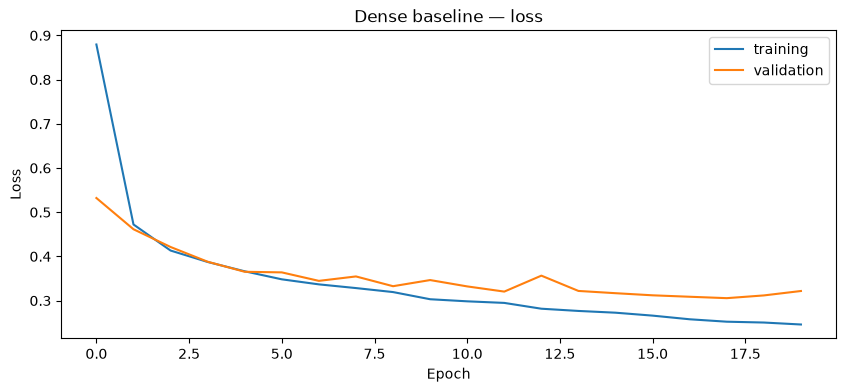

In [7]:
# Define one reusable function for both Dense and CNN learning curves.
def plot_training_history(history, title: str):

    # Extract the dictionary created by model.fit().
    logs = history.history

    # Find the epoch with the lowest validation loss.
    best_epoch = int(np.argmin(logs["val_loss"])) + 1

    # Print the most useful fitting diagnostics.
    print("Best validation-loss epoch:", best_epoch)
    print("Final training accuracy:   ", f'{logs["accuracy"][-1]:.4f}')
    print("Final validation accuracy: ", f'{logs["val_accuracy"][-1]:.4f}')
    print("Final training loss:       ", f'{logs["loss"][-1]:.4f}')
    print("Final validation loss:     ", f'{logs["val_loss"][-1]:.4f}')

    # Create the accuracy graph.
    plt.figure(figsize=(10, 4))

    # Plot training accuracy by epoch.
    plt.plot(logs["accuracy"], label="training")

    # Plot validation accuracy by epoch.
    plt.plot(logs["val_accuracy"], label="validation")

    # Add a descriptive title.
    plt.title(f"{title} — accuracy")

    # Label the horizontal axis.
    plt.xlabel("Epoch")

    # Label the vertical axis.
    plt.ylabel("Accuracy")

    # Identify the two curves.
    plt.legend()

    # Display the graph.
    plt.show()

    # Create a separate loss graph.
    plt.figure(figsize=(10, 4))

    # Plot training loss by epoch.
    plt.plot(logs["loss"], label="training")

    # Plot validation loss by epoch.
    plt.plot(logs["val_loss"], label="validation")

    # Add a descriptive title.
    plt.title(f"{title} — loss")

    # Label the horizontal axis.
    plt.xlabel("Epoch")

    # Label the vertical axis.
    plt.ylabel("Loss")

    # Identify the two curves.
    plt.legend()

    # Display the graph.
    plt.show()


# Diagnose the Dense baseline.
plot_training_history(dense_history, "Dense baseline")


In [8]:
# Evaluate the Dense model on the untouched test set.
dense_test_loss, dense_test_accuracy = dense_model.evaluate(
    x_test,
    y_test,
    verbose=0,
)

# Print final Dense test performance.
print("Dense test loss:", round(dense_test_loss, 4))
print("Dense test accuracy:", round(dense_test_accuracy, 4))


Dense test loss: 0.3673
Dense test accuracy: 0.8716


## 4. CNN model

The CNN keeps the spatial structure of the image.

This version uses:
- normalization;
- conservative data augmentation;
- two convolution blocks;
- two pooling operations rather than compressing 28×28 all the way to 1×1;
- Dropout after the Dense layer.

For a strict baseline experiment, set `use_augmentation=False` and `dropout_rate=0.0`.
Then introduce one regularization technique at a time.


In [9]:
# Define a function that can build either a plain CNN baseline or a regularized CNN.
def build_cnn_model(
    use_augmentation: bool = False,
    dropout_rate: float = 0.0,
) -> Sequential:

    # Start with layers common to every version of the CNN.
    layers = [
        # One input example is a 28×28 grayscale image.
        Input(shape=(28, 28)),

        # Add the explicit grayscale channel: 28×28 becomes 28×28×1.
        Reshape((28, 28, 1)),

        # Convert raw pixel values from 0–255 to 0–1.
        Rescaling(1.0 / 255),
    ]

    # Add augmentation only when the experiment requests it.
    if use_augmentation:
        layers.extend([
            # Shift images slightly vertically/horizontally during training.
            RandomTranslation(height_factor=0.05, width_factor=0.05),

            # Rotate images slightly during training.
            RandomRotation(factor=0.03),

            # Zoom slightly in or out during training.
            RandomZoom(height_factor=0.05, width_factor=0.05),
        ])

    # Add the actual CNN feature-extraction and classification layers.
    layers.extend([
        # Learn 32 filters of size 3×3 while keeping spatial size 28×28.
        Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same"),

        # Learn another 32 filters from the first set of feature maps.
        Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same"),

        # Reduce 28×28 feature maps approximately to 14×14.
        MaxPooling2D(pool_size=(2, 2)),

        # Increase feature depth from 32 to 64 learned feature maps.
        Conv2D(64, kernel_size=(3, 3), activation="relu", padding="same"),

        # Learn more complex features while retaining 64 output channels.
        Conv2D(64, kernel_size=(3, 3), activation="relu", padding="same"),

        # Reduce 14×14 feature maps approximately to 7×7.
        MaxPooling2D(pool_size=(2, 2)),

        # Convert the 7×7×64 tensor into one vector.
        Flatten(),

        # Combine the extracted CNN features for classification.
        Dense(128, activation="relu"),
    ])

    # Add Dropout only when dropout_rate is greater than zero.
    if dropout_rate > 0:
        layers.append(
            # During training, randomly disable this fraction of Dense outputs.
            Dropout(dropout_rate)
        )

    # Add the final 10-class probability output.
    layers.append(
        Dense(10, activation="softmax")
    )

    # Build the Sequential model from the prepared list of layers.
    model = Sequential(layers)

    # Configure training.
    model.compile(
        # Adam performs gradient-based weight updates.
        optimizer=Adam(),

        # Integer labels 0–9 require sparse categorical cross-entropy.
        loss=SparseCategoricalCrossentropy(),

        # Track classification accuracy.
        metrics=["accuracy"],
    )

    # Return the configured CNN.
    return model


### 4A. CNN baseline

First train without augmentation and without Dropout.
This gives us a clean reference. If it overfits, regularization can then be tested rather than added blindly.


In [10]:
# Build the clean CNN baseline.
cnn = build_cnn_model(
    use_augmentation=False,
    dropout_rate=0.0,
)

# Display every layer, output shape and parameter count.
cnn.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 467,818 (1.78 MB)

 Trainable params: 467,818 (1.78 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7945 - loss: 0.5861 - val_accuracy: 0.8714 - val_loss: 0.3574
Epoch 2/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8807 - loss: 0.3298 - val_accuracy: 0.8942 - val_loss: 0.2919
Epoch 3/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9026 - loss: 0.2678 - val_accuracy: 0.9032 - val_loss: 0.2677
Epoch 4/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9139 - loss: 0.2349 - val_accuracy: 0.9127 - val_loss: 0.2438
Epoch 5/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9243 - loss: 0.2060 - val_accuracy: 0.9155 - val_loss: 0.2294
Epoch 6/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9314 - loss: 0.1854 - val_accuracy: 0.9202 - val_loss: 0.2172
Epoch 7/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9384 - loss: 0.1656 - val_accuracy: 0.9235 - val_loss: 0.2081
Epoch 8/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9451 - loss: 0.1480 - val_accu

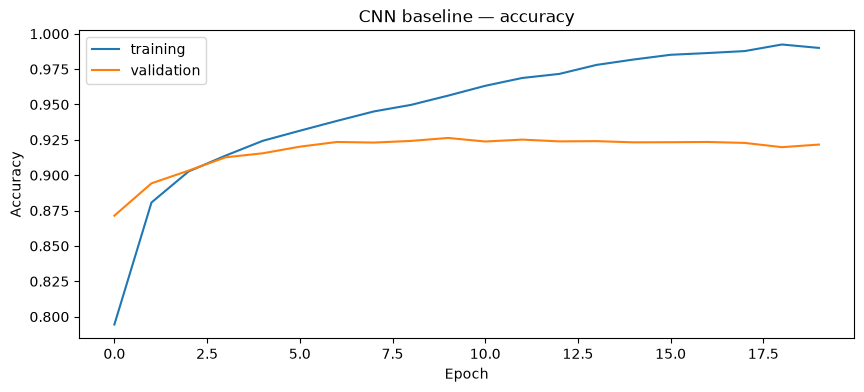

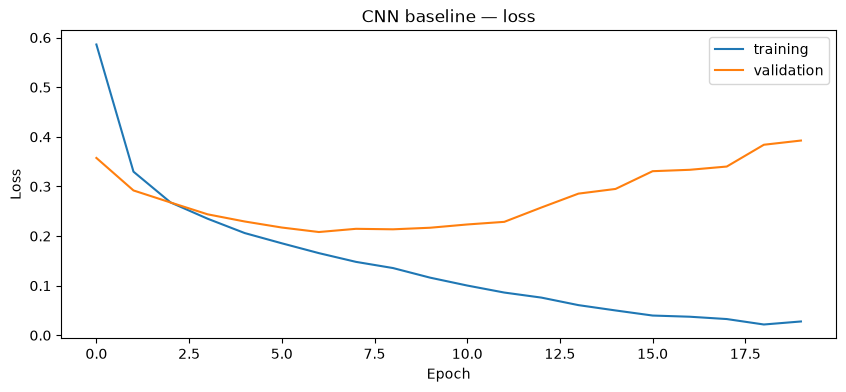

In [11]:
# Train the CNN baseline and keep the History object.
cnn_history = cnn.fit(
    # Same 48,000 training images used by the Dense baseline.
    x_train,

    # Same training labels.
    y_train,

    # Use 256 images before each optimizer update.
    batch_size=256,

    # Give the curves enough time to show whether overfitting begins.
    epochs=20,

    # Monitor the same 12,000 validation images used by the Dense baseline.
    validation_data=(x_val, y_val),

    # Show one progress line per epoch.
    verbose=1,
)

# Plot and print the CNN fitting diagnostics.
plot_training_history(cnn_history, "CNN baseline")


In [12]:
# Evaluate the CNN baseline on the untouched 10,000-image test set.
cnn_test_loss, cnn_test_accuracy = cnn.evaluate(
    x_test,
    y_test,
    verbose=0,
)

# Print final CNN test performance.
print("CNN test loss:", round(cnn_test_loss, 4))
print("CNN test accuracy:", round(cnn_test_accuracy, 4))

# Compare both models directly.
print()
print("Dense test accuracy:", round(dense_test_accuracy, 4))
print("CNN test accuracy:  ", round(cnn_test_accuracy, 4))


CNN test loss: 0.4293
CNN test accuracy: 0.9158

Dense test accuracy: 0.8716
CNN test accuracy:   0.9158


## 5. Optional fine-tuning experiment

Run this only after inspecting the CNN baseline curves.

This experiment changes regularization:
- conservative data augmentation is enabled;
- Dropout is set to 0.30.

The architecture otherwise remains the same, making the comparison easier to interpret.


In [13]:
# Build a second CNN with regularization.
cnn_tuned = build_cnn_model(
    use_augmentation=True,
    dropout_rate=0.30,
)

# Display the tuned architecture before training.
cnn_tuned.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape_1 (Reshape)             │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ (None, 28, 28, 1)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 28, 28, 1)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 467,818 (1.78 MB)

 Trainable params: 467,818 (1.78 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 167s 885ms/step - accuracy: 0.7178 - loss: 0.7605 - val_accuracy: 0.8147 - val_loss: 0.4997
Epoch 2/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 164s 872ms/step - accuracy: 0.8177 - loss: 0.4885 - val_accuracy: 0.8696 - val_loss: 0.3528
Epoch 3/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 171s 907ms/step - accuracy: 0.8429 - loss: 0.4185 - val_accuracy: 0.8821 - val_loss: 0.3207
Epoch 4/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 172s 917ms/step - accuracy: 0.8589 - loss: 0.3793 - val_accuracy: 0.8924 - val_loss: 0.2901
Epoch 5/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 172s 913ms/step - accuracy: 0.8703 - loss: 0.3488 - val_accuracy: 0.8962 - val_loss: 0.2822
Epoch 6/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 170s 906ms/step - accuracy: 0.8794 - loss: 0.3257 - val_accuracy: 0.9045 - val_loss: 0.2651
Epoch 7/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 169s 900ms/step - accuracy: 0.8871 - loss: 0.3051 - val_accuracy: 0.9070 - val_loss: 0.2540
Epoch 8/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 169s 897ms/step - accuracy: 0.8911 -

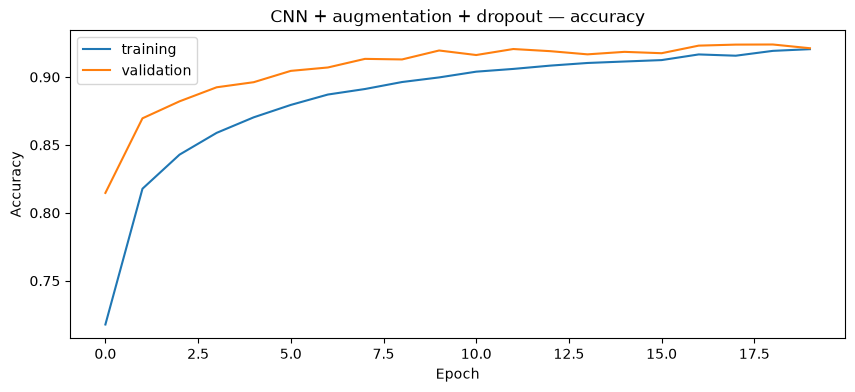

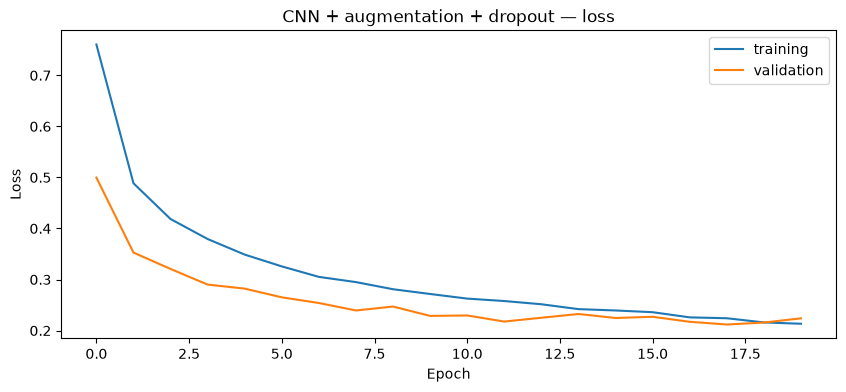

In [14]:
# Train the regularized CNN on exactly the same training/validation split.
cnn_tuned_history = cnn_tuned.fit(
    # Training images.
    x_train,

    # Training labels.
    y_train,

    # Keep batch size unchanged so the comparison remains controlled.
    batch_size=256,

    # Keep maximum epochs unchanged for the same reason.
    epochs=20,

    # Use the same validation set.
    validation_data=(x_val, y_val),

    # Show one progress line per epoch.
    verbose=1,
)

# Diagnose its fitting curves.
plot_training_history(cnn_tuned_history, "CNN + augmentation + dropout")


In [15]:
# Evaluate the tuned CNN on the untouched test set.
cnn_tuned_test_loss, cnn_tuned_test_accuracy = cnn_tuned.evaluate(
    x_test,
    y_test,
    verbose=0,
)

# Print all final test accuracies together.
print("Dense test accuracy:      ", round(dense_test_accuracy, 4))
print("CNN baseline accuracy:    ", round(cnn_test_accuracy, 4))
print("CNN tuned test accuracy:  ", round(cnn_tuned_test_accuracy, 4))


Dense test accuracy:       0.8716
CNN baseline accuracy:     0.9158
CNN tuned test accuracy:   0.9134


## 6. Detailed evaluation of the selected CNN

Choose which CNN you want to inspect below.
Initially `selected_cnn = cnn`.
After comparing results, change it to `cnn_tuned` if the tuned version generalizes better.


In [16]:
# Select the model to inspect in detail.
selected_cnn = cnn

# Predict class probabilities for every untouched test image.
y_pred_proba = selected_cnn.predict(x_test)

# Convert each 10-probability vector into the index of its largest probability.
y_pred = np.argmax(y_pred_proba, axis=1)

# Print precision, recall, F1-score and support for every class.
print(
    classification_report(
        y_test,
        y_pred,
        target_names=class_names,
    )
)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
              precision    recall  f1-score   support

 T-shirt/top       0.83      0.90      0.86      1000
     Trouser       1.00      0.98      0.99      1000
    Pullover       0.90      0.84      0.87      1000
       Dress       0.90      0.93      0.91      1000
        Coat       0.83      0.93      0.88      1000
      Sandal       0.98      0.98      0.98      1000
       Shirt       0.81      0.69      0.74      1000
     Sneaker       0.97      0.95      0.96      1000
         Bag       0.98      0.98      0.98      1000
  Ankle boot       0.96      0.97      0.97      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.91     10000
weighted avg       0.92      0.92      0.91     10000



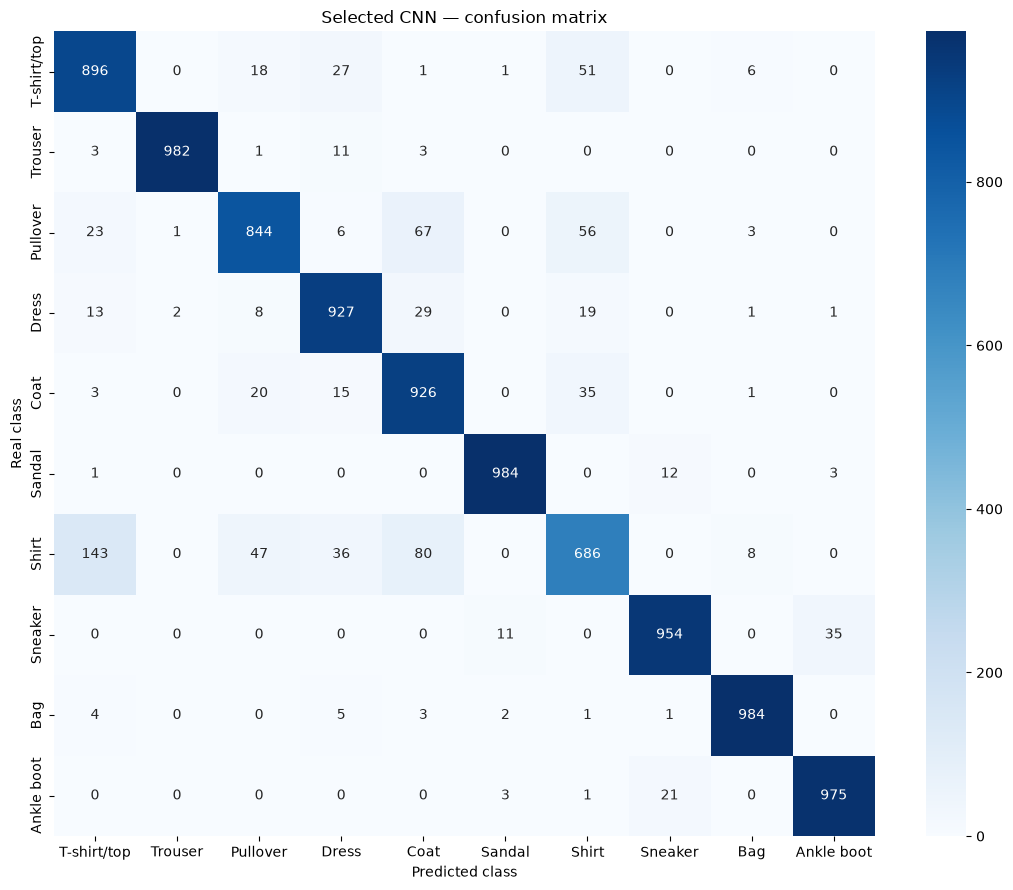

In [17]:
# Build the confusion matrix: rows = real classes, columns = predicted classes.
cm = confusion_matrix(y_test, y_pred)

# Create a readable heatmap.
plt.figure(figsize=(11, 9))

# Display integer counts and human-readable class labels.
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
)

# Label the horizontal axis.
plt.xlabel("Predicted class")

# Label the vertical axis.
plt.ylabel("Real class")

# Add a title.
plt.title("Selected CNN — confusion matrix")

# Prevent labels from being cut off.
plt.tight_layout()

# Display the matrix.
plt.show()


Number of test errors: 842


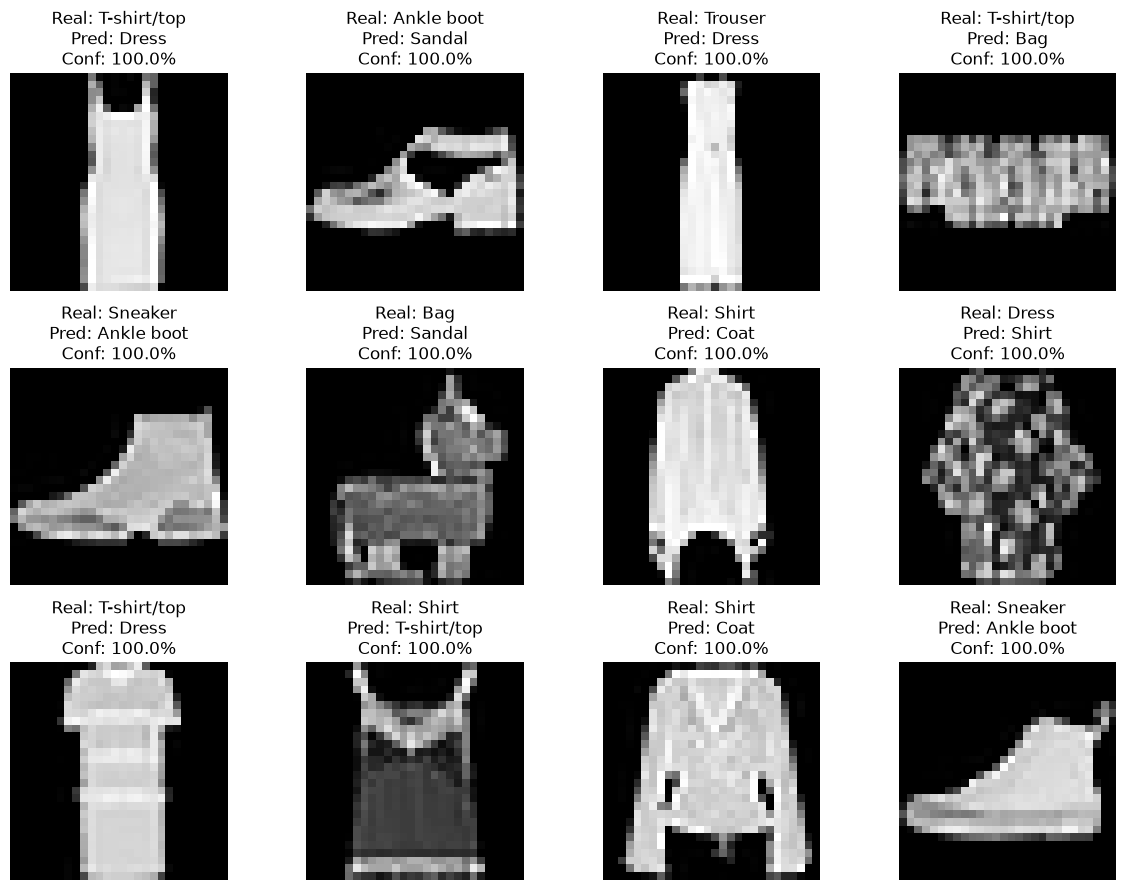

In [18]:
# Find all test-image indexes where prediction differs from the real label.
error_indices = np.where(y_pred != y_test)[0]

# Extract the confidence assigned to each model-selected class.
prediction_confidence = y_pred_proba[
    np.arange(len(y_pred)),
    y_pred,
]

# Keep confidence values only for wrong predictions.
error_confidence = prediction_confidence[error_indices]

# Sort wrong predictions from highest confidence to lowest confidence.
order = np.argsort(error_confidence)[::-1]

# Convert the sorting order back to real test-image indexes.
confident_errors = error_indices[order]

# Print the total number of errors.
print("Number of test errors:", len(error_indices))

# Display the 12 most confidently wrong predictions.
plt.figure(figsize=(12, 9))

# Loop over at most the first 12 errors.
for position, index in enumerate(confident_errors[:12]):

    # Create a 3×4 grid position.
    plt.subplot(3, 4, position + 1)

    # Display the original test image.
    plt.imshow(x_test[index], cmap="gray")

    # Show real class, predicted class and confidence.
    plt.title(
        f"Real: {class_names[y_test[index]]}\n"
        f"Pred: {class_names[y_pred[index]]}\n"
        f"Conf: {prediction_confidence[index]:.1%}"
    )

    # Hide axes.
    plt.axis("off")

# Prevent overlap.
plt.tight_layout()

# Display the error examples.
plt.show()


## 7. Inspect CNN feature maps

Instead of hard-coding layer numbers such as `layers[4]`, first list the layers.
This avoids mistakes when Dropout or augmentation changes layer indexes.


In [19]:
# Print every layer index, name and class.
for index, layer in enumerate(selected_cnn.layers):
    print(index, "-", layer.name, "-", layer.__class__.__name__)


0 - reshape - Reshape
1 - rescaling_1 - Rescaling
2 - conv2d - Conv2D
3 - conv2d_1 - Conv2D
4 - max_pooling2d - MaxPooling2D
5 - conv2d_2 - Conv2D
6 - conv2d_3 - Conv2D
7 - max_pooling2d_1 - MaxPooling2D
8 - flatten_1 - Flatten
9 - dense_4 - Dense
10 - dense_5 - Dense


In [20]:
# Automatically collect all convolution layers from the selected CNN.
conv_layers = [
    layer
    for layer in selected_cnn.layers
    if isinstance(layer, Conv2D)
]

# Print the convolution layers available for inspection.
for index, layer in enumerate(conv_layers):
    print(index, "-", layer.name, "-", layer.output.shape)


0 - conv2d - (None, 28, 28, 32)
1 - conv2d_1 - (None, 28, 28, 32)
2 - conv2d_2 - (None, 14, 14, 64)
3 - conv2d_3 - (None, 14, 14, 64)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Feature-map tensor shape: (1, 28, 28, 32)


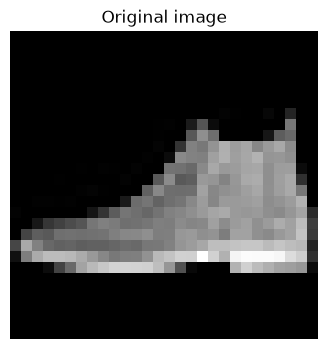

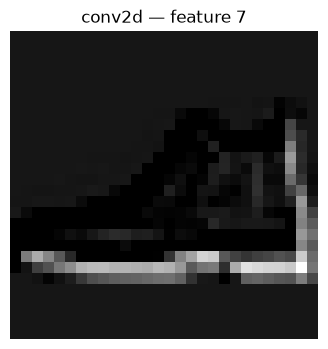

In [21]:
# Choose which convolution layer to inspect: 0 = first Conv2D.
conv_layer_number = 0

# Choose which test image to inspect.
image_number = 0

# Choose which feature channel/filter output to display.
feature_number = 7

# Select the requested convolution layer.
selected_conv_layer = conv_layers[conv_layer_number]

# Build a small model with the same CNN input but an intermediate layer as output.
feature_extractor = Model(
    inputs=selected_cnn.inputs,
    outputs=selected_conv_layer.output,
)

# Generate feature maps for only one image to avoid unnecessary computation.
feature_maps = feature_extractor.predict(
    x_test[image_number:image_number + 1]
)

# Check the resulting tensor shape.
print("Feature-map tensor shape:", feature_maps.shape)

# Stop with a clear message if the requested feature channel does not exist.
assert feature_number < feature_maps.shape[-1], (
    f"Feature {feature_number} does not exist; "
    f"this layer has {feature_maps.shape[-1]} channels."
)

# Display the original Fashion-MNIST image.
plt.figure(figsize=(4, 4))
plt.imshow(x_test[image_number], cmap="gray")
plt.title("Original image")
plt.axis("off")
plt.show()

# Display one learned feature map for that same image.
plt.figure(figsize=(4, 4))
plt.imshow(feature_maps[0, :, :, feature_number], cmap="gray")
plt.title(
    f"{selected_conv_layer.name} — feature {feature_number}"
)
plt.axis("off")
plt.show()


## What was removed or corrected from the original notebook

- Removed duplicate `train_test_split()` calls whose results were discarded.
- Removed the two consecutive NumPy seeds (`1` followed immediately by `42`).
- Removed `%pip install scikit-learn` from the normal execution path; package installation belongs to environment setup, not repeated model execution.
- Removed unused `ReLU`, `Accuracy` and `CategoricalCrossentropy` imports.
- Corrected the Dense comment: `Dense(128)` receives 64 values, not 128.
- Corrected comments that still referred to 60,000 training images after the 48,000/12,000 split.
- Corrected batch-size comments that said 1024 while the code used 512.
- Corrected epoch comments that said 30 while the code used 50.
- Changed `SparseCategoricalCrossentropy` to the explicit instance `SparseCategoricalCrossentropy()`.
- Kept Dense and CNN models in the same notebook, but gave them distinct names and histories.
- Replaced repeated hard-coded feature-map extractor blocks with one reusable inspection block.
- Added shape assertions and train/validation/test checks to detect accidental data leakage.
- Added a controlled CNN baseline and a separate optional regularized experiment.
